In [1]:
import os
os.chdir('../..')

In [2]:
import selfies as sf
from scipy.spatial.distance import cosine, euclidean
from sklearn.metrics import silhouette_score, adjusted_rand_score
from src.descriptors import SOAP, ACSF
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import polars as pl
from rdkit import DataStructs, Chem
from sklearn.mixture import GaussianMixture
from rdkit.Chem import AllChem
from src.clusters import ClusterAnalysis
from src.datasets import MaterialsProject

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-17 11:46:15.201 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
mp = MaterialsProject()
mp.load()

2026-02-17 11:46:17.175 | INFO     | src.datasets:_fetch_from_api:344 - Fetching 1000 stable oxides from API...
Retrieving SummaryDoc documents: 100%|██████████| 10325/10325 [00:10<00:00, 972.32it/s]
2026-02-17 11:46:30.636 | SUCCESS  | src.datasets:_fetch_from_api:373 - Dataset saved to data/Materials Project/stable_oxides.parquet


material_id,formula_pretty,energy_per_atom,raw_structure,crystal_system,space_group,volume
str,str,f64,str,str,str,f64
"""mp-1274279""","""FeO""",-8.19051,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",84.988477
"""mp-19921""","""PbO""",-5.800276,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",84.136627
"""mp-2097""","""SnO""",-6.108469,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",71.076593
"""mp-1692""","""CuO""",-5.466379,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",42.916449
"""mp-1336""","""PdO""",-5.853748,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",50.084274
…,…,…,…,…,…,…
"""mp-24129""","""MnH4(BrO)2""",-5.299537,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",139.885532
"""mp-23880""","""FeH4(ClO)2""",-5.265791,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",118.187118
"""mp-23853""","""CoH4(ClO)2""",-5.045306,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",113.58114


In [4]:
mp.add_acsf()

2026-02-17 11:46:32.601 | INFO     | src.datasets:_get_structures:379 - Reconstructing Pymatgen structures from JSON...
2026-02-17 11:46:32.779 | INFO     | src.datasets:add_acsf:442 - Computing Periodic ACSF for 1000 structures...
ACSF progress: 100%|██████████| 1000/1000 [00:02<00:00, 447.83it/s]
2026-02-17 11:46:35.573 | SUCCESS  | src.datasets:add_acsf:463 - ACSF embeddings added and Parquet updated.


In [ ]:
# mp.add_soap() # very slow

# Clustering on SOAP descriptors

Analyzing 1000 materials...
Feature Matrix Shape: (1000, 11046)
--- Running KMEANS ---


2026-02-17 11:47:55.553 | INFO     | src.clusters:plot_tsne:417 - Reducing dimensions from 11046 to 50 via PCA before t-SNE...


Found 7 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0335
Silhouette Score: 0.1493
Calinski-Harabasz Score: 125.3583
Generating t-SNE plot...
--- Running t-SNE (Perplexity=30)... ---
Generating interactive TSNE plot...


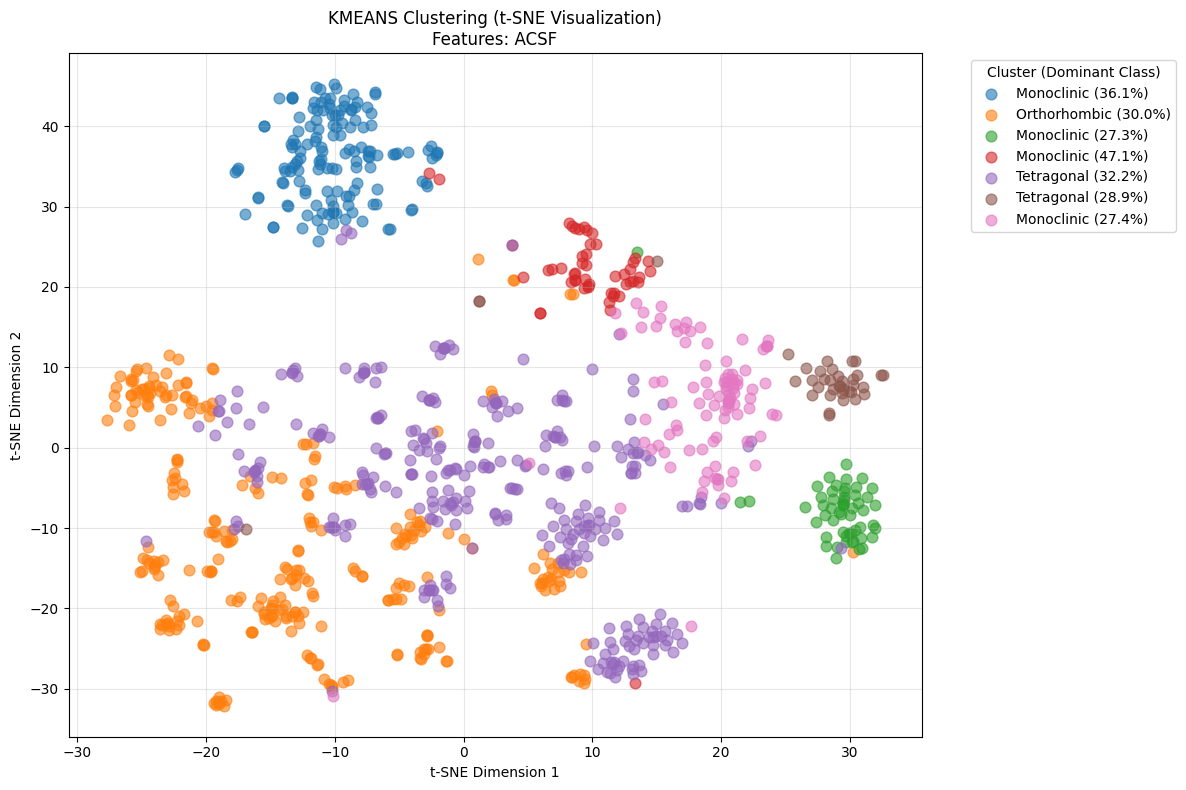

In [9]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


def analyze_materials_project(df):
    df_clean = df.drop_nulls(subset=["acsf_embedding"])
    
    if df_clean.height == 0:
        print("No valid embeddings found. Did you run with force_fetch=True?")
        return

    print(f"Analyzing {df_clean.height} materials...")

    #soap_matrix = np.array(df_clean["soap_embedding"].to_list())
    acsf_matrix = np.array(df_clean["acsf_embedding"].to_list())
    
    # Standardize them separately first (important because they have different scales)
    scaler_soap = StandardScaler()
    scaler_acsf = StandardScaler()
    
    #soap_scaled = scaler_soap.fit_transform(soap_matrix)
    acsf_scaled = scaler_acsf.fit_transform(acsf_matrix)
    
    # Concatenate: X = [SOAP_normalized | ACSF_normalized]
    #X_combined = np.hstack([soap_scaled, acsf_scaled])
    
    print(f"Feature Matrix Shape: {acsf_matrix.shape}")

    # 4. Define 'True Labels' for coloring (Optional)
    # Using 'crystal_system' (Cubic, Hexagonal, etc.) is great for validation
    true_labels = df_clean["crystal_system"].to_list()
    
    # Create Metadata DataFrame for hovering in interactive plots
    meta_df = df_clean.select([
        pl.col("material_id").alias("mol_id"), # Renaming to match ClusterAnalysis expectations
        pl.col("formula_pretty").alias("canonical_smiles"), # Using formula as 'SMILES'
        "crystal_system",
        "space_group"
    ])

    # 5. Run Clustering Analysis
    analyzer = ClusterAnalysis(acsf_matrix, true_labels=true_labels, meta_df=meta_df)
    
    # Run K-Means
    # n_clusters=7 is a good starting guess for crystal systems (7 systems)
    analyzer.run(method='kmeans', n_clusters=7)
    
    # Evaluate
    analyzer.evaluate()

    # 6. Plot t-SNE
    print("Generating t-SNE plot...")
    analyzer.plot_tsne(
        perplexity=30, 
        title_suffix="Features: ACSF", 
        highlight_top_overlaps=0 # Turn off if you don't want overlap circles
    )
    
    # Optional: Interactive Plot
    analyzer.plot_interactive(method='tsne', perplexity=30)

analyze_materials_project(mp.df)

# Mahalanobis Distances

In [10]:
X = np.array(mp.df["acsf_embedding"].to_list())
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
labels = gmm.fit_predict(X)
probs = gmm.predict_proba(X)

Pre-processing and running t-SNE...


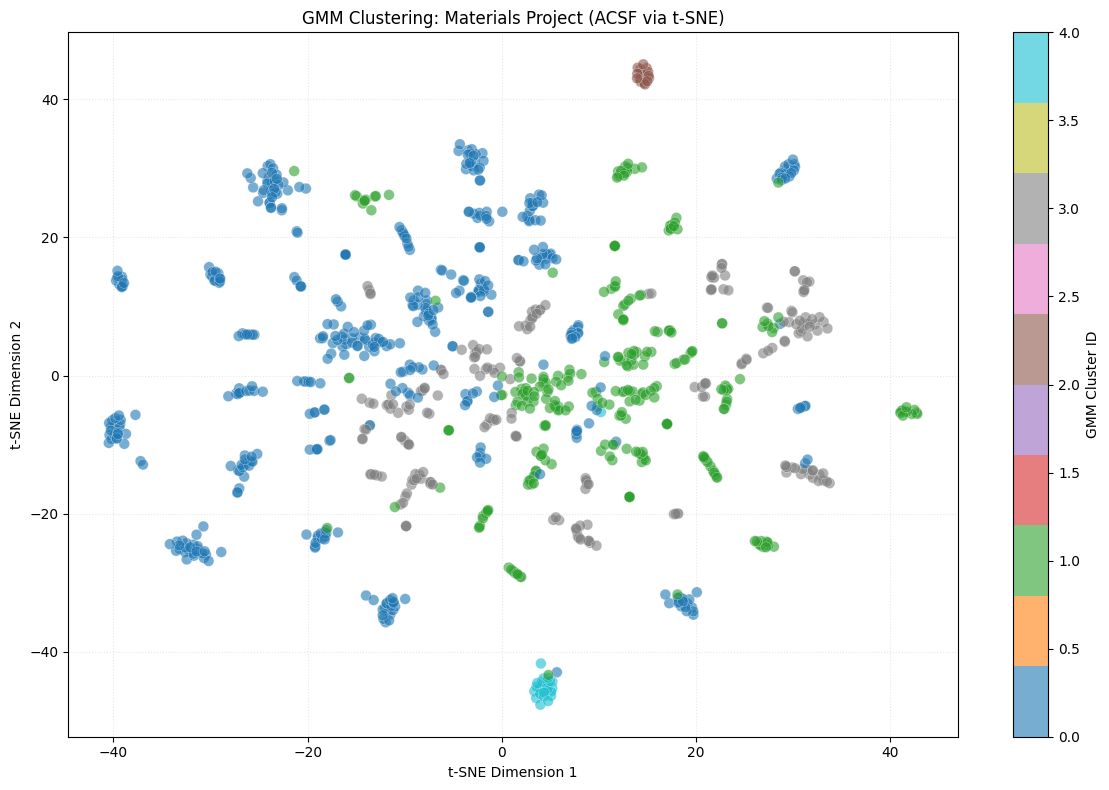

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_materials_gmm_tsne(X, labels, probs, perplexity=30, title="GMM Clustering: Materials Project (ACSF via t-SNE)"):
    """
    Plots GMM results using t-SNE for better local cluster separation.
    """
    print("Pre-processing and running t-SNE...")
    
    # 1. Scale features (Required for t-SNE to perform well)
    X_scaled = StandardScaler().fit_transform(X)
    
    # 2. PCA Pre-reduction (Speeds up t-SNE and reduces noise)
    # We reduce to 50 components before running t-SNE
    if X_scaled.shape[1] > 50:
        X_pca = PCA(n_components=50).fit_transform(X_scaled)
    else:
        X_pca = X_scaled

    # 3. Run t-SNE
    tsne = TSNE(
        n_components=2, 
        perplexity=perplexity, 
        init='pca', 
        learning_rate='auto', 
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_pca)
    
    # 4. Calculate Confidence for visualization
    confidence = np.max(probs, axis=1)
    
    # 5. Create Plot
    plt.figure(figsize=(12, 8))
    
    # c=labels: color by GMM cluster
    # alpha & s: scale by GMM probability (confidence)
    scatter = plt.scatter(
        X_tsne[:, 0], 
        X_tsne[:, 1], 
        c=labels, 
        cmap='tab10',  # Distinct colors for clusters
        alpha=0.6, 
        s=confidence * 60,
        edgecolors='white',
        linewidth=0.3
    )
    
    # 6. Formatting
    cb = plt.colorbar(scatter)
    cb.set_label('GMM Cluster ID')
    
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
# X = np.array(mp.df["acsf_embedding"].to_list())
# labels = gmm.fit_predict(X)
# probs = gmm.predict_proba(X)
plot_materials_gmm_tsne(X, labels, probs, perplexity=30)

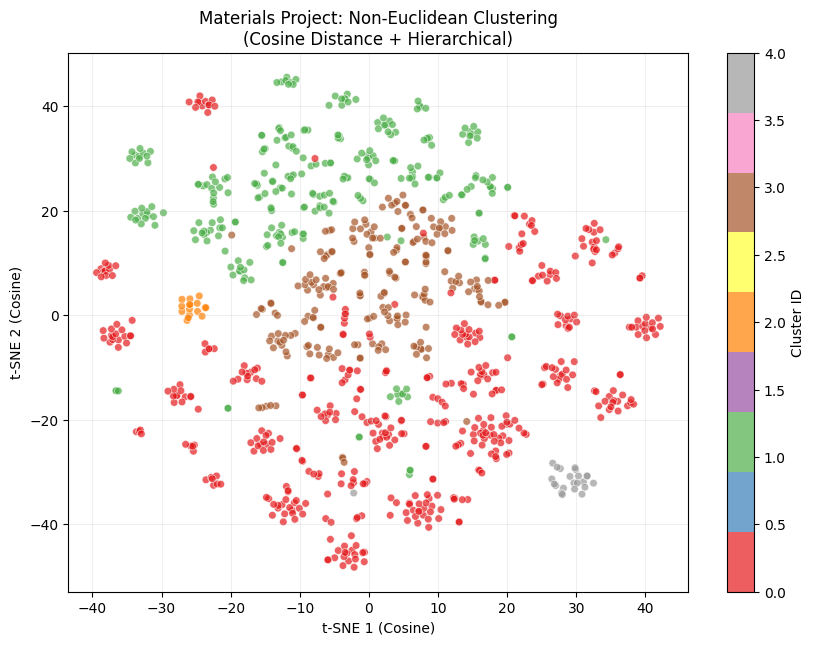

In [12]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import TSNE

# 1. Prepare Data
# ACSF vectors often benefit from scaling before distance calculation
X = np.array(mp.df["acsf_embedding"].to_list())
X_scaled = StandardScaler().fit_transform(X)

# 2. Clustering with Cosine Distance
# 'average' linkage works well with cosine distance
cluster_model = AgglomerativeClustering(
    n_clusters=5, 
    metric='cosine', 
    linkage='average'
)
labels = cluster_model.fit_predict(X_scaled)

# 3. Visualization using t-SNE
# Note: We tell t-SNE to also use cosine metric so the plot matches the clustering logic
tsne = TSNE(
    n_components=2, 
    metric='cosine', 
    init='random', 
    perplexity=30, 
    random_state=42
)
X_embedded = tsne.fit_transform(X_scaled)

# 4. Plotting
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=labels, 
    cmap='Set1', 
    alpha=0.7, 
    s=30,
    edgecolors='white',
    linewidth=0.5
)

plt.colorbar(scatter, label='Cluster ID')
plt.title("Materials Project: Non-Euclidean Clustering\n(Cosine Distance + Hierarchical)")
plt.xlabel("t-SNE 1 (Cosine)")
plt.ylabel("t-SNE 2 (Cosine)")
plt.grid(True, alpha=0.2)
plt.show()